In [2]:
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# %%
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

# Xem các bảng trong database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [27]:
# %%
df = pd.read_sql("SELECT * FROM NearsestSample", conn)
# %%
df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)].reset_index()

df.head()

,index,id,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,SpatialDim,TimeDim
0,5,6,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,NaN,24.705610,28.1,ALB,2010
1,16,17,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,0.18,25.515699,7.4,ALB,2015
2,19,20,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,0.17,25.326576,7.4,ALB,2014
3,29,30,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,0.18,25.150570,7.4,ALB,2013
4,36,37,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,NaN,17.841043,28.1,ALB,2011


In [29]:
# %%
df = df.drop(columns=["index","id","x7","SpatialDim"], errors="ignore")
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'time']
df.columns = tables
df.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
0,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,24.705610,28.1,2010
1,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,25.515699,7.4,2015
2,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,25.326576,7.4,2014
3,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,25.150570,7.4,2013
4,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,17.841043,28.1,2011


In [30]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  float64
 1   air_pollution            10890 non-null  float64
 2   alcohol_consumption      10735 non-null  float64
 3   BMI                      10956 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   time                     10956 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 856.1 KB


In [31]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution               66
alcohol_consumption        221
BMI                          0
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
time                         0
dtype: int64

In [32]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10956.0,55.593244,35.512469,8.701838,32.768090,40.400000,62.100000,1.375000e+02
air_pollution,10956.0,8290.686407,319532.735705,0.000000,51.066000,193.716500,582.009500,2.509519e+07
alcohol_consumption,10956.0,41.429338,19.257525,2.680089,26.664454,40.181983,52.406960,9.921560e+01
BMI,10956.0,22.424149,17.616987,0.238787,7.450371,22.200000,27.200000,9.247079e+01
cholesterol,10956.0,2.903514,1.426160,0.800000,1.300000,3.300000,4.000000,5.300000e+00
diabetes,10956.0,16.683322,16.735358,2.800000,5.694480,8.000000,20.600000,8.310288e+01
glucose,10956.0,8.657804,4.239293,2.100000,5.900000,8.000000,9.800000,2.980000e+01
physical_activities,10956.0,26.063816,11.766169,3.335438,17.580842,23.772923,32.636906,6.920515e+01
tobacco,10956.0,23.755696,14.737694,0.000000,12.475000,23.000000,32.800000,7.700000e+01
time,10956.0,2012.500000,1.707903,2010.000000,2011.000000,2012.500000,2014.000000,2.015000e+03


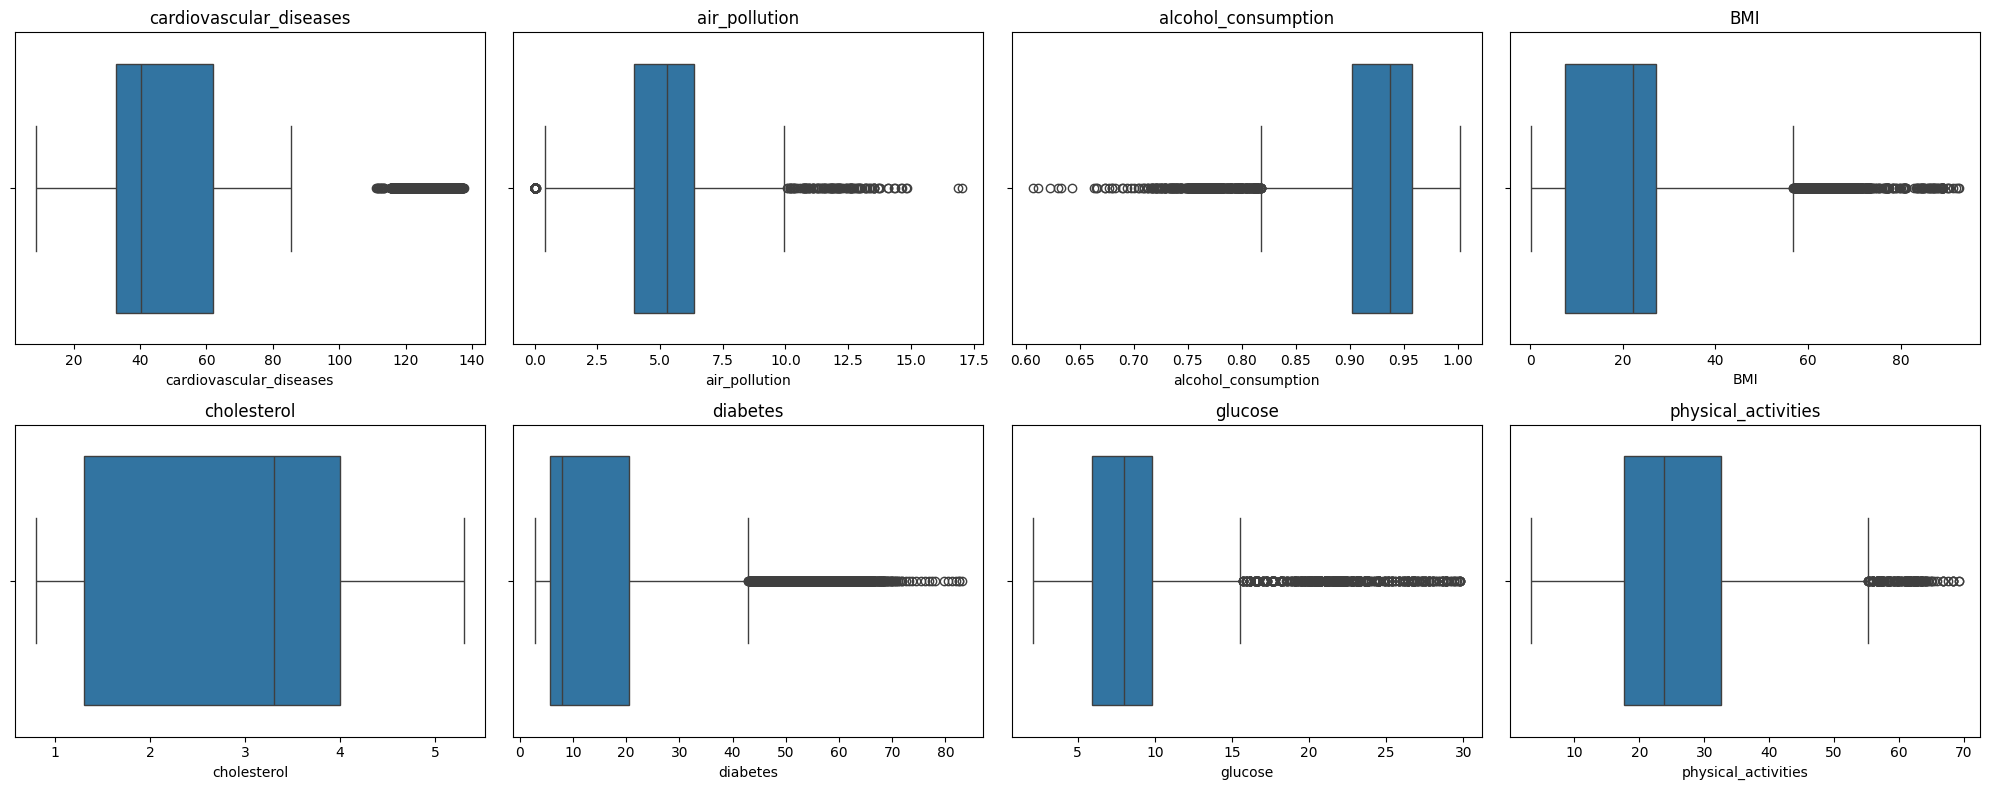

In [38]:
df.air_pollution = np.log1p(df.air_pollution)
cols = df.columns[:-1]   # bỏ cột cuối

plt.figure(figsize=(20,8))

for i, col in enumerate(cols[:8]):   # lấy 8 cột đầu
    plt.subplot(2, 4, i+1)           # 2 hàng 4 cột
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'time'], inplace=True)
X = df_model

In [12]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [13]:
coef, inter = run_for_linear(X, y)

MSE: 282150362.62036276
R2: 0.02479862594680282
Coefficients: [-3.21280596e+00 -3.54639955e-04  6.42044967e+01 -1.03141028e+01
 -9.65959299e+01 -2.66639474e+01  5.19738103e+02 -1.36449880e+02
  9.27862157e+00]
Intercept: 26792.857677011158


In [14]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

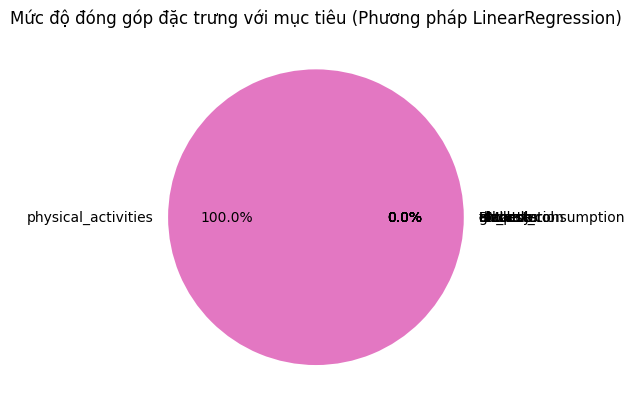

In [15]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [16]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [17]:
impor = run_for_random_forest(X, y)

MSE: 6348329.153211693
R2: 0.9780581557448361
Feature Importances: [0.09236212 0.03035352 0.07576736 0.03949398 0.02917034 0.05423801
 0.19870474 0.17013783 0.3097721 ]


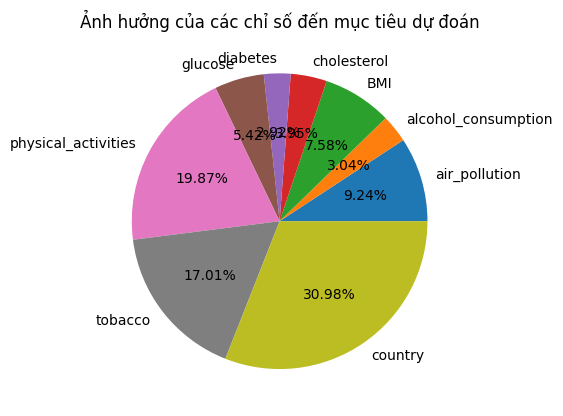

In [18]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [19]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

In [20]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

KeyError: 'country'

In [ ]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
5,6,2.233311,-0.025854,-0.914436,0.208663,1.470089,-0.566690,-0.178765,-0.115438,28.1,2010
16,17,2.267103,-0.025772,-1.560797,0.237046,1.399968,2.240585,-0.060816,-0.046586,7.4,2015
19,20,2.261471,-0.025766,-1.557443,0.231370,1.399968,-0.536811,-0.060816,-0.062661,7.4,2014
29,30,2.253023,-0.024440,-0.970825,0.225693,1.470089,-0.542787,-0.084406,-0.077620,7.4,2013
36,37,2.241759,-0.024191,-1.528894,0.214340,1.470089,-0.560714,-0.155175,-0.698881,28.1,2011


In [ ]:
# %%
corr_matrix = df_scaled[features].corr()

corr_matrix

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco
air_pollution,1.000000,0.049037,-0.073053,0.074180,0.387696,-0.079928,0.038528,0.024034
alcohol_consumption,0.049037,1.000000,-0.003418,0.001190,0.025023,-0.011489,-0.003486,0.003944
BMI,-0.073053,-0.003418,1.000000,-0.036386,-0.055325,-0.095930,-0.004755,-0.096532
cholesterol,0.074180,0.001190,-0.036386,1.000000,-0.134465,-0.137240,0.278344,0.171401
diabetes,0.387696,0.025023,-0.055325,-0.134465,1.000000,0.039834,0.058659,0.066522
glucose,-0.079928,-0.011489,-0.095930,-0.137240,0.039834,1.000000,0.170396,0.178838
physical_activities,0.038528,-0.003486,-0.004755,0.278344,0.058659,0.170396,1.000000,0.348503
tobacco,0.024034,0.003944,-0.096532,0.171401,0.066522,0.178838,0.348503,1.000000


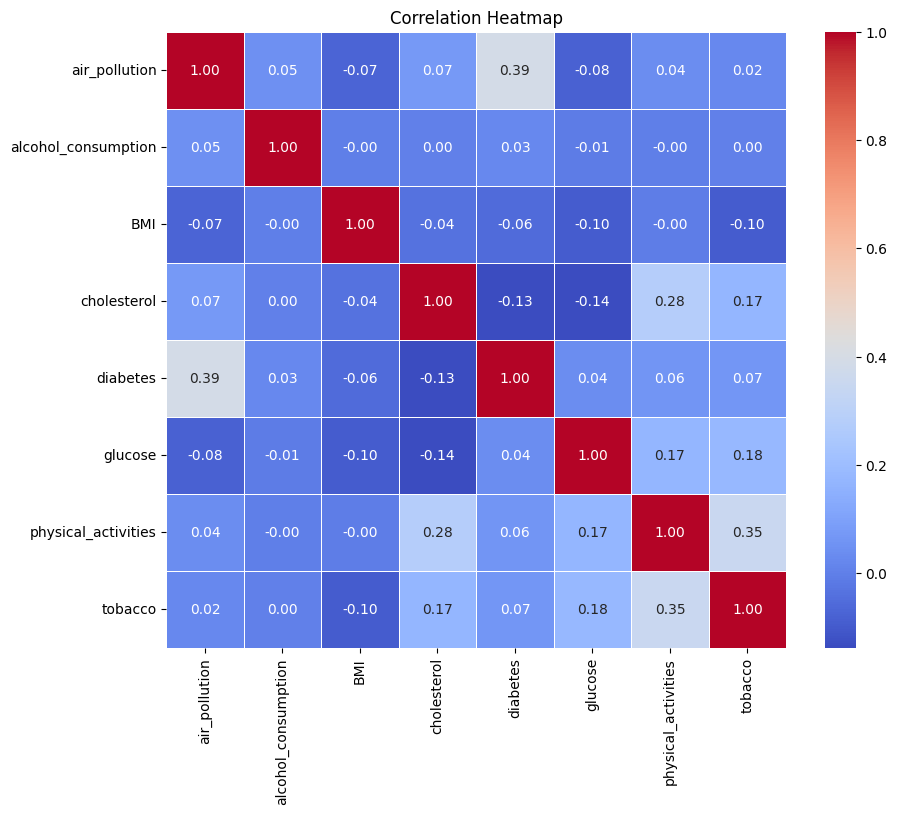

In [ ]:
# %%
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()